# **Import Libraries**

In [ ]:
import sys
print(sys.executable)

In [1]:
# ── STEP 1 — Imports ──────────────────────────────────────
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


***Set-UP***

In [2]:
import os

# REPLACE WITH THIS (Local VS Code)
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))    # your local project folder
os.makedirs(f'{BASE_PATH}/model', exist_ok=True)
os.makedirs(f'{BASE_PATH}/results', exist_ok=True)

# **Load data sets and augmentation**

In [3]:
# Training transform — augmented
# Teaches model to handle real world imperfect digits
train_transform = transforms.Compose([
    transforms.ToTensor(),

    # Random rotation ±15 degrees
    # Tilted digit still same digit
    transforms.RandomRotation(degrees=15),

    # Random shift and scale
    # Digit at different position/size = still same digit
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),   # shift up to 10%
        scale=(0.9, 1.1)        # zoom in/out 10%
    ),

    # Random erase small region
    # Teaches model to handle incomplete/partial digits
    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.1)
    ),

    transforms.Normalize((0.5,), (0.5,))
])

# Test transform — clean, no augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Apply different transforms to each
train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True,
                                transform=train_transform)
test_dataset  = datasets.MNIST(root='./data', train=False,
                                download=True,
                                transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 60000 | Test: 10000


# **Visualize data set**

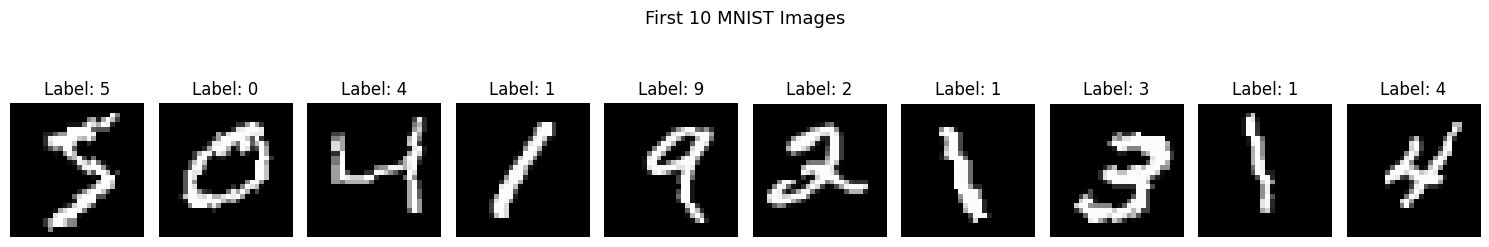

In [4]:
# ── STEP 4 — Visualize Data ───────────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.suptitle('First 10 MNIST Images', fontsize=13)
plt.tight_layout()
plt.show()

# **BUilding the model**

In [5]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2   = nn.Conv2d(32, 64, 3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(64 * 7 * 7, 128)
        self.fc2     = nn.Linear(128, 10)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def check(self, loss):
        if self.best_loss is None:
            self.best_loss = loss
        elif loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter   = 0
            print(f"  ✅ Improved to {loss:.4f}")
        else:
            self.counter += 1
            print(f"  ⚠️ No improvement {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
                print("🛑 Early stopping triggered!")

# **Model+Optimizer+schedueler**

In [6]:
model     = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    
)

# Initialize early stopping here
early_stop = EarlyStopping(patience=5, min_delta=0.001)

***Training Loop***

In [7]:
train_losses = []
EPOCHS=20
for epoch in range(EPOCHS):

    # model.train() enables dropout during training
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Average loss for this epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # LR Scheduler checks every epoch
    # Reduces learning rate if loss stops improving
    scheduler.step(epoch_loss)

    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}')

print("Training Complete!")

Epoch 1/20 - Loss: 0.6360
Epoch 2/20 - Loss: 0.3162
Epoch 3/20 - Loss: 0.2559
Epoch 4/20 - Loss: 0.2235
Epoch 5/20 - Loss: 0.1967
Epoch 6/20 - Loss: 0.1858
Epoch 7/20 - Loss: 0.1703
Epoch 8/20 - Loss: 0.1648
Epoch 9/20 - Loss: 0.1542
Epoch 10/20 - Loss: 0.1481
Epoch 11/20 - Loss: 0.1399
Epoch 12/20 - Loss: 0.1394
Epoch 13/20 - Loss: 0.1317
Epoch 14/20 - Loss: 0.1307
Epoch 15/20 - Loss: 0.1280
Epoch 16/20 - Loss: 0.1242
Epoch 17/20 - Loss: 0.1154
Epoch 18/20 - Loss: 0.1157
Epoch 19/20 - Loss: 0.1193
Epoch 20/20 - Loss: 0.1147
Training Complete!


# **Model Saved**

In [8]:
torch.save(model.state_dict(),
           f'{BASE_PATH}/model/airdraw_model.pth')
print("Model saved successfully!")

Model saved successfully!


# **Plotting curves**

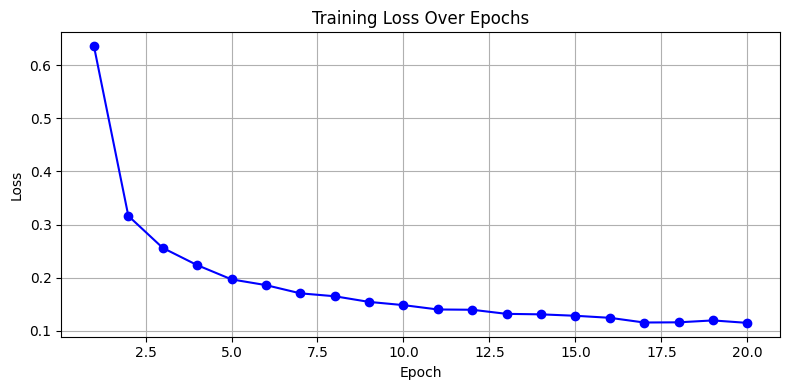

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1),   # ← fixed range
         train_losses, marker='o', color='blue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/results/loss_curve.png')
plt.show()

# **Model Evaluation**

Test Accuracy: 99.36%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      1.00       892
           6       0.99      1.00      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



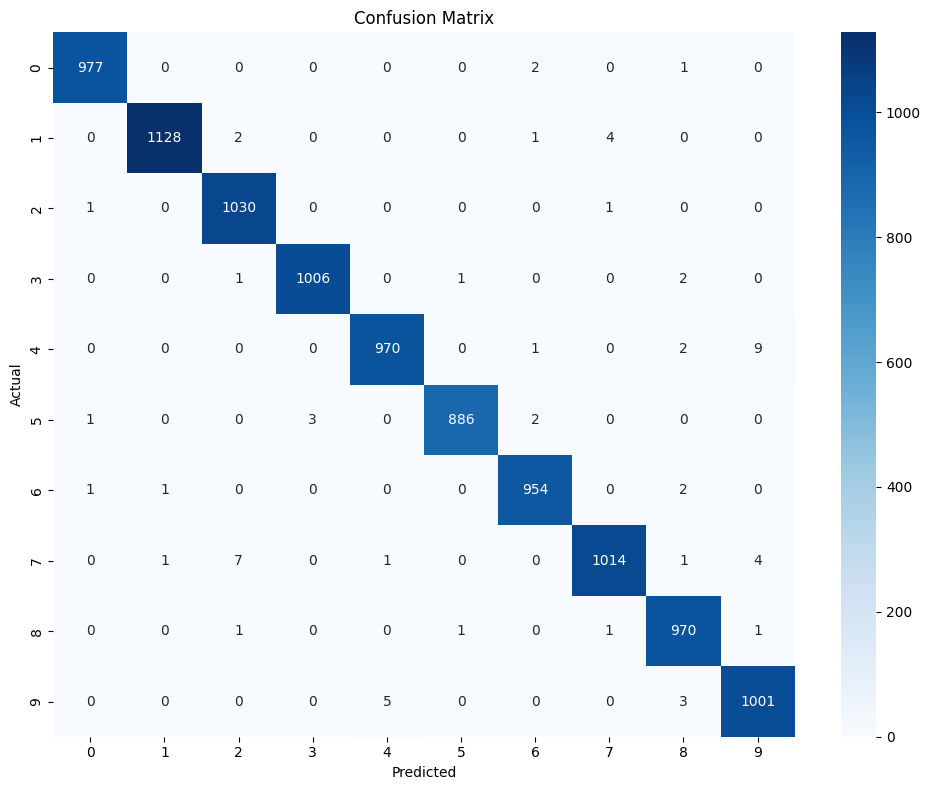

In [10]:
model.eval()
correct = 0
total   = 0
all_predictions = []
all_labels      = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

print(classification_report(all_labels, all_predictions,
      target_names=[str(i) for i in range(10)]))

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/results/confusion_matrix.png')
plt.show()

# **Confusion Matrix**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      1.00       892
           6       0.99      1.00      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



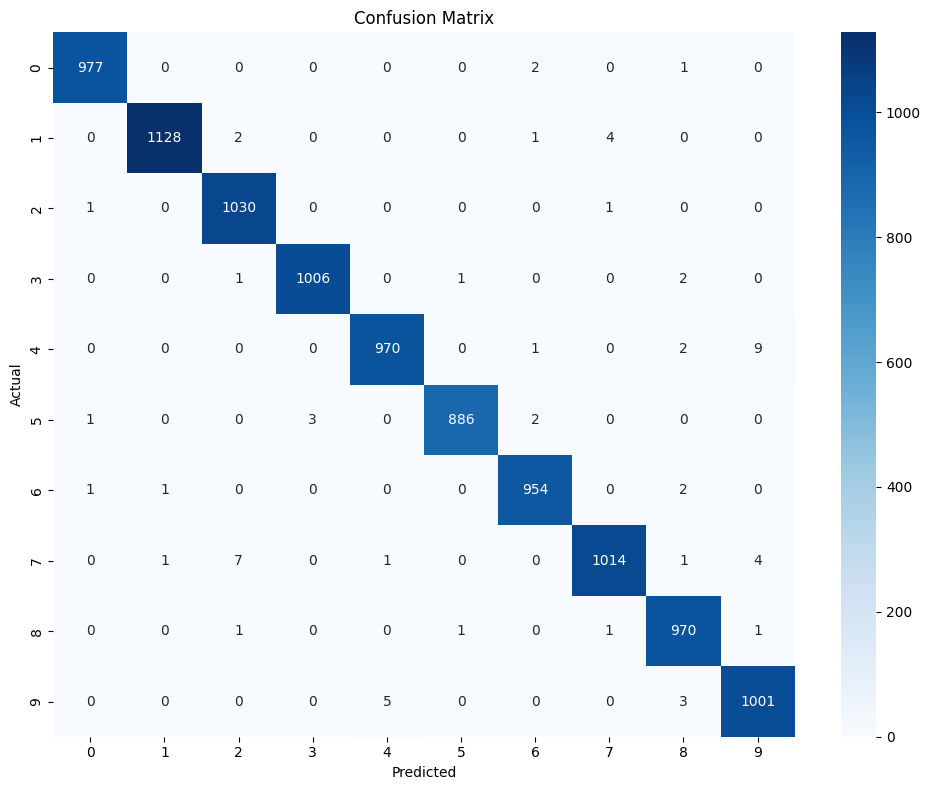

In [11]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_predictions = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Precision Recall F1
print(classification_report(all_labels, all_predictions,
      target_names=[str(i) for i in range(10)]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/results/confusion_matrix.png')
plt.show()

K-Fold Cross validation

In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler

def run_kfold(dataset, k=2):

    kfold   = KFold(n_splits=k, shuffle=True, random_state=42)
    indices = list(range(len(dataset)))
    results = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(indices)):
        print(f"\n{'='*50}")
        print(f"FOLD {fold+1}/{k}")
        print(f"{'='*50}")

        # Samplers for this fold
        train_sampler = SubsetRandomSampler(train_ids)
        val_sampler   = SubsetRandomSampler(val_ids)

        train_loader_kf = DataLoader(dataset, batch_size=64,
                                     sampler=train_sampler)
        val_loader_kf   = DataLoader(dataset, batch_size=64,
                                     sampler=val_sampler)

        # Fresh model each fold
        model_kf  = MNISTNet()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model_kf.parameters(), lr=0.001)
        es        = EarlyStopping(patience=3)

        for epoch in range(20):
            # Train
            model_kf.train()
            for images, labels in train_loader_kf:
                optimizer.zero_grad()
                outputs = model_kf(images)
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Validate
            model_kf.eval()
            val_loss = 0.0
            correct  = 0
            total    = 0
            with torch.no_grad():
                for images, labels in val_loader_kf:
                    outputs   = model_kf(images)
                    val_loss += criterion(outputs, labels).item()
                    _, pred   = torch.max(outputs, 1)
                    correct  += (pred == labels).sum().item()
                    total    += labels.size(0)

            val_loss = val_loss / len(val_loader_kf)
            accuracy = 100 * correct / total

            es.check(val_loss)
            if es.stop:
                break

        results.append(accuracy)
        print(f"Fold {fold+1} Final Accuracy: {accuracy:.2f}%")

    print(f"\n{'='*50}")
    print(f"K-Fold Results ({k} folds):")
    print(f"Average Accuracy : {np.mean(results):.2f}%")
    print(f"Std Deviation    : {np.std(results):.2f}%")
    print(f"Best Fold        : {max(results):.2f}%")
    print(f"Worst Fold       : {min(results):.2f}%")

    return results

# Run it
kfold_results = run_kfold(train_dataset, k=5)


FOLD 1/5
  ✅ Improved to 0.1677
  ✅ Improved to 0.1462
  ✅ Improved to 0.1264
  ✅ Improved to 0.1140
  ✅ Improved to 0.1111
  ✅ Improved to 0.0999
  ✅ Improved to 0.0944
  ⚠️ No improvement 1/3
